# Лабораторная работа №1
**Предмет:** язык Python для анализа данных  
**ФИО:** Филиппов Владимир Леонидович   
**Группа:** K3339   
**ИСУ:** 292209

## Цель работы
Провести анализ показателей населения, географических и временных характеристик городов в составе федеративного государства, используя инструменты Python для обработки данных, расчётов и выявления закономерностей. Исследовать роль неизменяемости данных в обеспечении целостности анализа.

## Страна и субъекты
- Страна: США (федерация)
- Субъекты (штаты): Техас, Флорида, Калифорния

## Выбор городов (по 5 на штат, включая столицу штата)
### Техас
- Остин (столица)
- Хьюстон
- Даллас
- Сан-Антонио
- Эль-Пасо

### Флорида
- Таллахасси (столица)
- Майами
- Орландо
- Тампа
- Пенсакола

### Калифорния
- Сакраменто (столица)
- Лос-Анджелес
- Сан-Диего
- Сан-Франциско
- Фресно

Период для восхода/заката (только Калифорния, т.к. 1 часовой пояс): 2026-06-01 - 2026-06-07 (средние значения, местное время).
Для Техаса и Флориды указаны Восход/Закат как '-' потому что внутри субъекта несколько часовых поясов, а по заданию этот пункт требуется именно при одном часовом поясе в субъекте.

| Город | Штат | Lat (6) | Lon (6) | Lat (2) | Lon (2) | Часовой пояс | Восход (среднее) | Закат (среднее) | Столица штата | Плотность (чел/кв милю) |
| - | - | - | - | - | - | - | - | - | - | - |
| Остин (Austin) | Техас (Texas) | 30.267220 | -97.743060 | 30.27 | -97.74 | America/Chicago | - | - | Да | 3006.36 |
| Хьюстон (Houston) | Техас (Texas) | 29.762780 | -95.383060 | 29.76 | -95.38 | America/Chicago | - | - | Нет | 3613.38 |
| Даллас (Dallas) | Техас (Texas) | 32.779170 | -96.806940 | 32.78 | -96.81 | America/Chicago | - | - | Нет | 3840.90 |
| Сан-Антонио (San Antonio) | Техас (Texas) | 29.425000 | -98.493890 | 29.43 | -98.49 | America/Chicago | - | - | Нет | 3001.91 |
| Эль-Пасо (El Paso) | Техас (Texas) | 31.759170 | -106.488610 | 31.76 | -106.49 | America/Denver | - | - | Нет | 2626.69 |
| Таллахасси (Tallahassee) | Флорида (Florida) | 30.438260 | -84.280730 | 30.44 | -84.28 | America/New_York | - | - | Да | 1926.00 |
| Майами (Miami) | Флорида (Florida) | 25.780000 | -80.210000 | 25.78 | -80.21 | America/New_York | - | - | Нет | 12284.47 |
| Орландо (Orlando) | Флорида (Florida) | 28.540000 | -81.380000 | 28.54 | -81.38 | America/New_York | - | - | Нет | 2774.65 |
| Тампа (Tampa) | Флорида (Florida) | 27.950000 | -82.460000 | 27.95 | -82.46 | America/New_York | - | - | Нет | 3376.40 |
| Пенсакола (Pensacola) | Флорида (Florida) | 30.421390 | -87.217220 | 30.42 | -87.22 | America/Chicago | - | - | Нет | 2359.48 |
| Сакраменто (Sacramento) | Калифорния (California) | 38.581600 | -121.494400 | 38.58 | -121.49 | America/Los_Angeles | 05:42 | 20:26 | Да | 5323.40 |
| Лос-Анджелес (Los Angeles) | Калифорния (California) | 34.052200 | -118.243700 | 34.05 | -118.24 | America/Los_Angeles | 05:42 | 20:01 | Нет | 8304.20 |
| Сан-Диего (San Diego) | Калифорния (California) | 32.715700 | -117.161100 | 32.72 | -117.16 | America/Los_Angeles | 05:41 | 19:53 | Нет | 4234.24 |
| Сан-Франциско (San Francisco) | Калифорния (California) | 37.774900 | -122.419400 | 37.77 | -122.42 | America/Los_Angeles | 05:48 | 20:28 | Нет | 18634.65 |
| Фресно (Fresno) | Калифорния (California) | 36.737800 | -119.787100 | 36.74 | -119.79 | America/Los_Angeles | 05:41 | 20:14 | Нет | 4795.54 |

## 1. Организация данных

Вопрос: Какой выигрыш в памяти? Почему получен данный результат?  ￼
- Выигрыш в памяти почти отсутствует (практически 0%).
- Причина: округление координат меняет только значение числа, но не его тип. В Python и 30.267220, и 30.27 хранятся как float, а размер float почти одинаковый независимо от количества знаков.
- Существенная экономия памяти была бы, если хранить координаты не как float, а как int (например, умножить координаты на 1_000_000 и хранить целые), или хранить данные в numpy-массивах.

## 2. Анализ плотности населения и расстояний

Вопрос: Как оптимально реализовать перевод в радианы? В каких единицах измерения целесообразно хранить координаты?  ￼
- Координаты целесообразно хранить в градусах, потому что так они обычно указаны в источниках и их проще проверять глазами.
- Перевод в радианы нужно делать только перед вычислением расстояния, потому что sin и cos работают в радианах.
- Оптимально:
    - если данных мало (как у нас 15 городов) - использовать math.radians() прямо внутри функции расстояния;
    - если данных много - один раз перевести массивы широт и долгот в радианы (векторно через numpy) и дальше считать расстояния без повторных преобразований.

Вопрос: Какова потеря в точности расстояния? Целесообразна ли для данной задачи высокая точность? Сравнения в %  ￼
- Для нашей выборки (15 городов) при округлении координат до 2 знаков:
    - максимальная потеря точности расстояния до столицы страны (Washington, D.C.) - примерно 0.028%;
    - максимальная потеря точности расстояния до столицы своего штата - примерно 0.47%.
- Вывод:
    - для крупных расстояний (до столицы страны) низкой точности (2 знака) обычно достаточно, так как ошибка очень мала;
    - для внутрисубъектных сравнений (до столицы штата) высокая точность полезнее, потому что ошибка относительно больше (хотя в нашей выборке все равно меньше 1%).
- Практический смысл: если задача чувствительна к небольшим различиям (например, сравнивать близкие города), высокая точность предпочтительнее.

## 3. Анализ часовых поясов

Вопрос: Сделайте вывод - можно ли однозначно определить часовой пояс по координатам?  ￼
- Однозначно определить часовой пояс только по координатам нельзя.
- Причина: границы часовых поясов задаются административно (по границам регионов), а не строго по долготе.
- Поэтому два города с похожей долготой могут оказаться в разных поясах, и наоборот.

Вопрос: Проанализируйте при совпадении часовых поясов в одном субъекте данные по заходу и восходу солнца  ￼
- Даже если часовой пояс одинаковый, время восхода и заката может отличаться, потому что оно зависит еще и от широты/долготы (географии), а не только от часов.
- В нашем наборе:
- California имеет один часовой пояс, и можно сравнить города внутри него - восход/закат отличаются между San Francisco и Los Angeles из-за разной широты и положения у океана/внутри материка.
- Texas и Florida имеют более одного пояса (в нашей выборке), поэтому анализ восхода/заката по условию задания для них не обязателен (условие было “при одном часовом поясе в субъекте”).

## 4. Анализ структур данных

Вопрос: Почему некоторые атрибуты (например координаты) неизменяемые, а другие изменяемые?  ￼
- Координаты лучше делать неизменяемыми, потому что:
    - они используются в расчетах расстояний;
    - случайное изменение координат ломает все результаты анализа;
    - поэтому их стоит защищать от случайной правки.
- Название города и часовой пояс можно считать изменяемыми, потому что:
    - названия могут официально меняться (переименование);
    - часовые пояса и правила перевода часов тоже могут меняться решениями властей, а база tz обновляется, чтобы отражать такие изменения.  ￼

Вопрос: Попробуйте выполнить операцию модификации одного из защищенных атрибутов. Зафиксируйте поведение системы.  ￼
- В упрощенной версии кода координаты хранятся как кортеж (lat, lon). Кортеж в Python неизменяемый, поэтому попытка изменить элемент координат приводит к ошибке.
- Пример поведения: если сделать coords[0] = 0, Python выдаст ошибку типа TypeError: 'tuple' object does not support item assignment.
- Это и есть “защита” - программа не позволит тихо испортить координаты.

## Код (src)

Farthest from Washington, D.C. (hi): San Francisco - California - 3918.9 km
Farthest from own state capital (hi): El Paso - Texas - 849.5 km

Top 5 errors after rounding (percent):
San Antonio - Texas country: 0.028 % state: 0.208 %
Pensacola - Florida country: 0.022 % state: 0.12 %
Austin - Texas country: 0.02 % state: 0.0 %
Tallahassee - Florida country: 0.017 % state: 0.0 %
Dallas - Texas country: 0.011 % state: 0.13 %

Time zones per state: {'Texas': 2, 'Florida': 2, 'California': 1}

Correlation (longitude vs UTC offset hours): 0.984


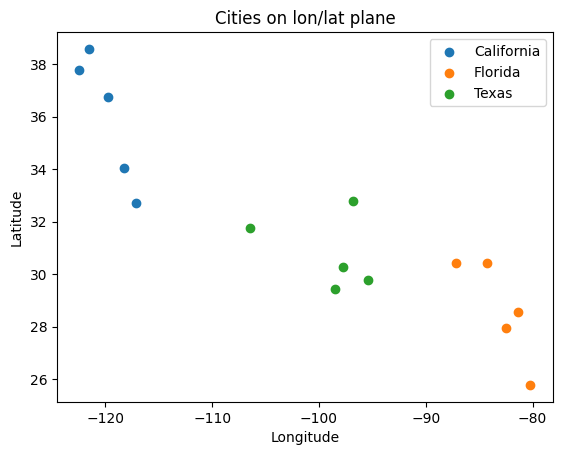

In [1]:
import math
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

import numpy as np
import matplotlib.pyplot as plt


# 1) Данные (высокая точность, 6 знаков)
cities_hi = [
    # Техас
    {"city": "Austin", "state": "Texas", "coords": (30.267220, -97.743060), "tz": "America/Chicago", "cap": True,  "density": 3006.36},
    {"city": "Houston", "state": "Texas", "coords": (29.762780, -95.383060), "tz": "America/Chicago", "cap": False, "density": 3613.38},
    {"city": "Dallas", "state": "Texas", "coords": (32.779170, -96.806940), "tz": "America/Chicago", "cap": False, "density": 3840.90},
    {"city": "San Antonio", "state": "Texas", "coords": (29.425000, -98.493890), "tz": "America/Chicago", "cap": False, "density": 3001.91},
    {"city": "El Paso", "state": "Texas", "coords": (31.759170, -106.488610), "tz": "America/Denver", "cap": False, "density": 2626.69},

    # Флорида
    {"city": "Tallahassee", "state": "Florida", "coords": (30.438260, -84.280730), "tz": "America/New_York", "cap": True,  "density": 1926.00},
    {"city": "Miami", "state": "Florida", "coords": (25.780000, -80.210000), "tz": "America/New_York", "cap": False, "density": 12284.47},
    {"city": "Orlando", "state": "Florida", "coords": (28.540000, -81.380000), "tz": "America/New_York", "cap": False, "density": 2774.65},
    {"city": "Tampa", "state": "Florida", "coords": (27.950000, -82.460000), "tz": "America/New_York", "cap": False, "density": 3376.40},
    {"city": "Pensacola", "state": "Florida", "coords": (30.421390, -87.217220), "tz": "America/Chicago", "cap": False, "density": 2359.48},

    # Калифорния
    {"city": "Sacramento", "state": "California", "coords": (38.581600, -121.494400), "tz": "America/Los_Angeles", "cap": True,  "density": 5323.40},
    {"city": "Los Angeles", "state": "California", "coords": (34.052200, -118.243700), "tz": "America/Los_Angeles", "cap": False, "density": 8304.20},
    {"city": "San Diego", "state": "California", "coords": (32.715700, -117.161100), "tz": "America/Los_Angeles", "cap": False, "density": 4234.24},
    {"city": "San Francisco", "state": "California", "coords": (37.774900, -122.419400), "tz": "America/Los_Angeles", "cap": False, "density": 18634.65},
    {"city": "Fresno", "state": "California", "coords": (36.737800, -119.787100), "tz": "America/Los_Angeles", "cap": False, "density": 4795.54},
]


# создаем новый список городов с округленными координатами
def make_low_precision(cities, ndigits=2):
    cities_lo = []
    for c in cities:
        lat, lon = c["coords"]
        c2 = c.copy()
        c2["coords"] = (round(lat, ndigits), round(lon, ndigits))
        cities_lo.append(c2)
    return cities_lo


cities_lo = make_low_precision(cities_hi, 2)


# расстояние (формула гаверсинуса), ввод - градусы
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    c = 2 * math.asin(math.sqrt(a))
    return R * c


CAPITAL_USA = (38.895110, -77.036370)  # Вашингтон


def add_distances(cities, usa_cap_coords):
    # добавка расстояния до столицы США
    for c in cities:
        lat, lon = c["coords"]
        c["dist_country_km"] = haversine_km(lat, lon, usa_cap_coords[0], usa_cap_coords[1])


def add_state_distances(cities):
    # собтраем координаты столиц штатов
    state_cap = {}
    for c in cities:
        if c["cap"]:
            state_cap[c["state"]] = c["coords"]

    # считаем расстояния до столицы своего штата
    for c in cities:
        cap_lat, cap_lon = state_cap[c["state"]]
        lat, lon = c["coords"]
        c["dist_state_km"] = haversine_km(lat, lon, cap_lat, cap_lon)


def key_city(c):
    return (c["city"], c["state"])


def compare_errors(cities_hi_list, cities_lo_list):
    # делаем словарь для быстрого доступа по ключу (город, штат)
    lo_map = {key_city(c): c for c in cities_lo_list}

    rows = []
    for c in cities_hi_list:
        k = key_city(c)
        c_lo = lo_map[k]

        err_country = abs(c_lo["dist_country_km"] - c["dist_country_km"]) / c["dist_country_km"] * 100
        err_state = abs(c_lo["dist_state_km"] - c["dist_state_km"]) / c["dist_state_km"] * 100 if c["dist_state_km"] != 0 else 0.0

        rows.append({
            "city": c["city"],
            "state": c["state"],
            "err_country_%": err_country,
            "err_state_%": err_state,
        })

    # сортируем по ошибке
    rows.sort(key=lambda x: x["err_country_%"], reverse=True)
    return rows


# Часовые пояса
def timezones_per_state(cities):
    d = {}
    for c in cities:
        st = c["state"]
        d.setdefault(st, set()).add(c["tz"])
    return {st: len(tzs) for st, tzs in d.items()}


def utc_offset_hours(dt_utc, tz_name):
    local = dt_utc.astimezone(ZoneInfo(tz_name))
    return local.utcoffset().total_seconds() / 3600


def longitude_offset_correlation(cities):
    # фиксируем дату, чтобы DST меньше мешал
    dt = datetime(2026, 1, 15, 12, 0, tzinfo=timezone.utc)

    lons = []
    offsets = []
    for c in cities:
        lat, lon = c["coords"]
        lons.append(lon)
        offsets.append(utc_offset_hours(dt, c["tz"]))

    # корреляция Пирсона
    return float(np.corrcoef(lons, offsets)[0, 1])


# Визуализация (точки lon/lat)
def plot_points(cities):
    plt.figure()
    states = sorted(set(c["state"] for c in cities))
    for st in states:
        xs = [c["coords"][1] for c in cities if c["state"] == st]  # lon
        ys = [c["coords"][0] for c in cities if c["state"] == st]  # lat
        plt.scatter(xs, ys, label=st)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Cities on lon/lat plane")
    plt.legend()
    plt.show()


def main():
    # добавляем расстояния для hi и lo
    add_distances(cities_hi, CAPITAL_USA)
    add_state_distances(cities_hi)

    add_distances(cities_lo, CAPITAL_USA)
    add_state_distances(cities_lo)

    # самый дальний от столицы США (hi)
    far = max(cities_hi, key=lambda c: c["dist_country_km"])
    print("Farthest from Washington, D.C. (hi):", far["city"], "-", far["state"], "-", round(far["dist_country_km"], 1), "km")

    # самый дальний от столицы своего штата (hi)
    far_state = max(cities_hi, key=lambda c: c["dist_state_km"])
    print("Farthest from own state capital (hi):", far_state["city"], "-", far_state["state"], "-", round(far_state["dist_state_km"], 1), "km")

    # ошибки от округления
    errors = compare_errors(cities_hi, cities_lo)
    print("\nTop 5 errors after rounding (percent):")
    for r in errors[:5]:
        print(r["city"], "-", r["state"], "country:", round(r["err_country_%"], 3), "%", "state:", round(r["err_state_%"], 3), "%")

    # часовые пояса
    tz_counts = timezones_per_state(cities_hi)
    print("\nTime zones per state:", tz_counts)

    # корреляция долгота - utc offset
    corr = longitude_offset_correlation(cities_hi)
    print("\nCorrelation (longitude vs UTC offset hours):", round(corr, 3))

    # график
    plot_points(cities_hi)


main()